# BLiSS 1.0 usage example

This notebook shows how to load a spectrum, run the BLiSS line-search pipeline, inspect candidate lines, and generate ISIS helper files when needed.

In [1]:
from pathlib import Path
import sys

# Use the local package when running the notebook from the repository.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import bliss



from bliss import (
    load_text_spectrum,
    load_fits_spectrum,
    rebin_bins,
    rebin_snr,
    rebin_resolution,
    find_emission_lines,
    add_most_probable_ion,
    plot_line_prob,
    create_bliss_results_folder,
)
from bliss.isis_interface import write_isis_line_model_files, run_bliss_for_isis

print("Using BLiSS from:", bliss.__file__)

Using BLiSS from: /Users/graciela/Desktop/git/BLiSS/bliss/__init__.py


## 1. Create a timestamped output folder

Every run creates a folder named as:

```text
results/YYYY-MM-DD_HH-MM-SS_bliss/
```

This avoids overwriting previous runs and makes each analysis traceable.

In [2]:
results_dir = create_bliss_results_folder(PROJECT_ROOT / "results", "bliss")
results_dir

PosixPath('/Users/graciela/Desktop/git/BLiSS/results/2026-05-29_11-00-08_bliss')

## 2. Load a spectrum from a text file

The text loader reads the standard four-column BLiSS format:

```text
E_low   E_high   spectral_value   uncertainty
```

It returns arrays compatible with the old-style BLiSS call.

In [3]:
text_path = PROJECT_ROOT / "examples" / "xmm.dat"
energy, values, errors, bin_width = load_text_spectrum(text_path)

print(energy.shape, values.shape, errors.shape)
print("Energy range:", energy.min(), energy.max())

(242,) (242,) (242,)
Energy range: 0.3400000035762787 9.980000019073486


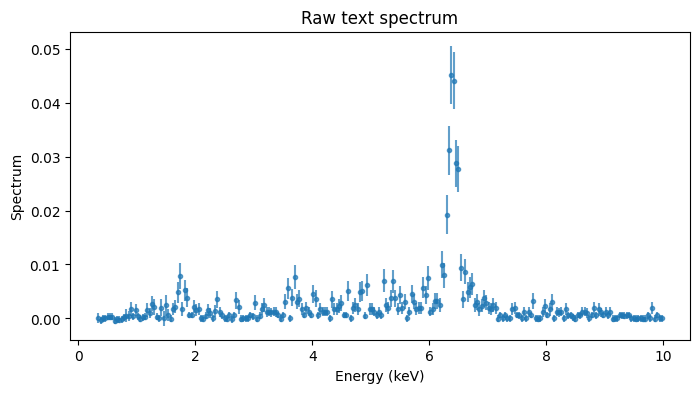

In [4]:
plt.figure(figsize=(8, 4))
plt.errorbar(energy, values, yerr=errors, fmt=".", alpha=0.7)
plt.xlabel("Energy (keV)")
plt.ylabel("Spectrum")
plt.title("Raw text spectrum")
plt.show()

## 3. Rebinning options

The modular package keeps the same rebinning functions used by the old example:

- `rebin_bins`
- `rebin_snr`
- `rebin_resolution`

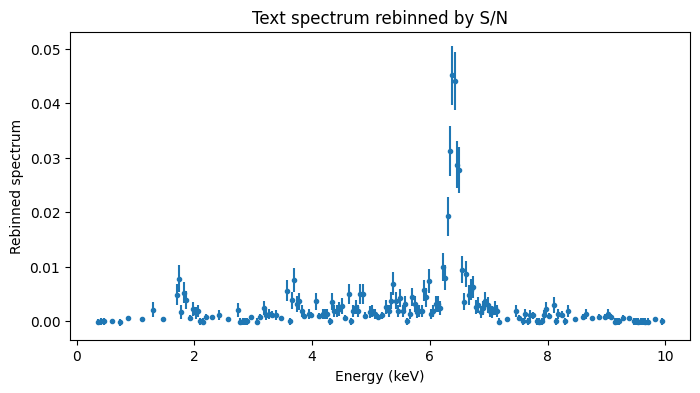

In [5]:
rx_bins, ry_bins, rsy_bins = rebin_bins(energy, values, errors, 1)
rx_snr, ry_snr, rsy_snr = rebin_snr(energy, values, errors, 0.8)

plt.figure(figsize=(8, 4))
plt.errorbar(rx_snr, ry_snr, yerr=rsy_snr, fmt=".")
plt.xlabel("Energy (keV)")
plt.ylabel("Rebinned spectrum")
plt.title("Text spectrum rebinned by S/N")
plt.show()

## 4. Run the BLiSS blind line search

The high-level user-facing function is still:

```python
find_emission_lines(energy, values, errors)
```

Internally, this now calls the modular pipeline rather than one monolithic script.

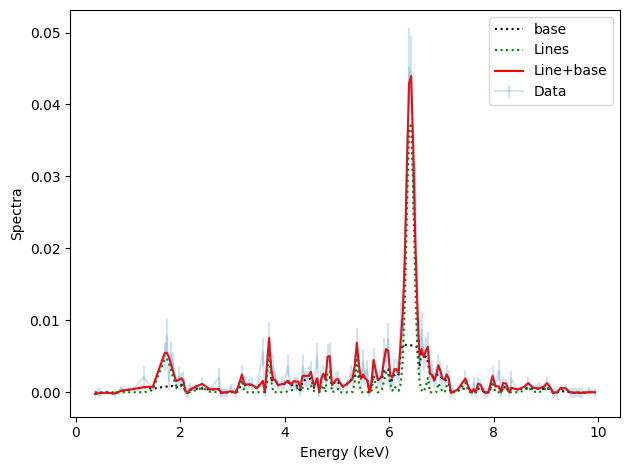

,center,sigma,amplitude,ecenter,esigma,eamplitude,base_on_line,value_on_line,noise_on_block,snr,relative_power,area,earea,ew,cluster_probability
0,1.723098,0.106224,0.004762,0.057076,0.051994,0.000988,0.000848,0.005233,0.001439,3.310066,0.721138,0.001268,0.000674,1056.840180,0.13
1,2.020009,0.042951,0.000813,0.090650,0.096632,0.001354,0.001043,0.001569,0.000924,0.880431,0.201420,0.000088,0.000245,inf,0.31
2,2.397862,0.081581,0.000637,0.311216,0.279566,0.001614,0.000542,0.001192,0.000567,1.123720,0.374746,0.000130,0.000555,240.539801,0.31
3,3.170500,0.025173,0.001816,0.081766,0.036752,0.002705,0.000780,0.002473,0.000777,2.336755,0.520275,0.000115,0.000239,97.946703,0.76
4,3.696944,0.026663,0.005978,0.009613,0.007220,0.001511,0.001612,0.007593,0.001300,4.597864,0.649765,0.000400,0.000148,244.479429,1.00
5,4.317100,0.141101,0.000660,0.287527,0.296476,0.000750,0.000943,0.001280,0.000783,0.843325,0.151593,0.000234,0.000558,inf,0.31
6,4.491370,0.014836,0.000781,94.722136,61.832708,3.999124,0.001904,0.002849,0.001089,0.716879,0.198663,0.000029,0.191738,29.749109,0.76
7,4.723717,0.013105,0.002109,8.454242,14.904737,5.395013,0.001578,0.002560,0.001035,2.037439,0.237305,0.000069,0.193952,36.320266,0.76
8,4.840229,0.013115,0.009178,0.424480,12.158986,19.783057,0.002086,0.005033,0.001340,6.848384,0.413886,0.000302,0.707971,113.768484,1.00
9,5.003625,0.013188,0.001082,5.040913,9.169170,1.673245,0.001332,0.001832,0.000938,1.152977,0.158209,0.000036,0.060648,20.732879,0.76


In [6]:
xmm_lines = find_emission_lines(
    rx_snr,
    ry_snr,
    rsy_snr,
    show_plot=True,
    output_dir=results_dir,
    plot_name="xmm_bliss_fit.png",
)

xmm_lines

In [7]:
xmm_lines.to_csv(results_dir / "xmm_candidate_lines.csv", index=False)
print("Saved:", results_dir / "xmm_candidate_lines.csv")
print("Number of candidates:", len(xmm_lines))

Saved: /Users/graciela/Desktop/git/BLiSS/results/2026-05-29_11-00-08_bliss/xmm_candidate_lines.csv
Number of candidates: 25


## 5. Atomic-line identification

BLiSS detection is blind. Identification is a separate optional step.

Here we add the most probable compatible ion within a Doppler velocity window.

In [8]:
xmm_identified = add_most_probable_ion(xmm_lines, v_doppler_kms=1200)
xmm_identified.to_csv(results_dir / "xmm_identified_lines.csv", index=False)
xmm_identified

,ion,energy_keV,doppler_kms,center,sigma,amplitude,ecenter,esigma,eamplitude,base_on_line,value_on_line,noise_on_block,snr,relative_power,area,earea,ew,cluster_probability
0,fe_xxvi,1.728918,-1009.153202,1.723098,0.106224,0.004762,0.057076,0.051994,0.000988,0.000848,0.005233,0.001439,3.310066,0.721138,0.001268,0.000674,1056.840180,0.13
1,p_vi,2.018563,214.752450,2.020009,0.042951,0.000813,0.090650,0.096632,0.001354,0.001043,0.001569,0.000924,0.880431,0.201420,0.000088,0.000245,inf,0.31
2,s_xii,2.393379,561.626566,2.397862,0.081581,0.000637,0.311216,0.279566,0.001614,0.000542,0.001192,0.000567,1.123720,0.374746,0.000130,0.000555,240.539801,0.31
3,ar_vi,3.179082,-809.262142,3.170500,0.025173,0.001816,0.081766,0.036752,0.002705,0.000780,0.002473,0.000777,2.336755,0.520275,0.000115,0.000239,97.946703,0.76
4,ca_x,3.705666,-705.685880,3.696944,0.026663,0.005978,0.009613,0.007220,0.001511,0.001612,0.007593,0.001300,4.597864,0.649765,0.000400,0.000148,244.479429,1.00
5,sc_xx,4.315196,132.293214,4.317100,0.141101,0.000660,0.287527,0.296476,0.000750,0.000943,0.001280,0.000783,0.843325,0.151593,0.000234,0.000558,inf,0.31
6,ti_v,4.504421,-868.591915,4.491370,0.014836,0.000781,94.722136,61.832708,3.999124,0.001904,0.002849,0.001089,0.716879,0.198663,0.000029,0.191738,29.749109,0.76
7,ti_xx,4.715303,534.900237,4.723717,0.013105,0.002109,8.454242,14.904737,5.395013,0.001578,0.002560,0.001035,2.037439,0.237305,0.000069,0.193952,36.320266,0.76
8,ca_xix,4.821661,1154.492109,4.840229,0.013115,0.009178,0.424480,12.158986,19.783057,0.002086,0.005033,0.001340,6.848384,0.413886,0.000302,0.707971,113.768484,1.00
9,v_xvi,5.011487,-470.302053,5.003625,0.013188,0.001082,5.040913,9.169170,1.673245,0.001332,0.001832,0.000938,1.152977,0.158209,0.000036,0.060648,20.732879,0.76


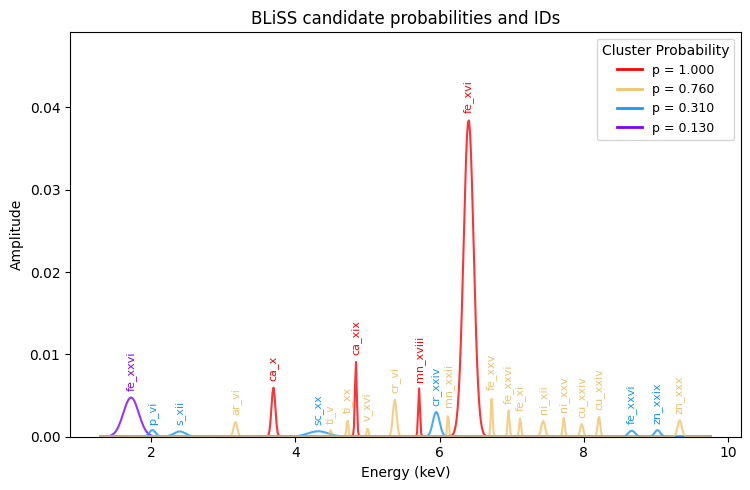

In [9]:
fig, ax = plot_line_prob(xmm_identified, show=False)

ax.set_title("BLiSS candidate probabilities and IDs")

fig.savefig(
    results_dir / "xmm_line_probability.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## 6. Load a spectrum from FITS products

This is the new input route.

The FITS loader uses `astropy` and can read:

- a source spectrum file (`pha_path`),
- an optional background spectrum (`background_path`),
- an optional RMF file (`rmf_path`) to obtain the energy grid from the `EBOUNDS` extension.

The loader returns a `Spectrum` container by default.

In [10]:
fits_dir = PROJECT_ROOT / "examples" / "fits_spectrum_data"
print(sorted(p.name for p in fits_dir.iterdir()))

['bkglp.fits', 'med4.ds', 'r_plateau.rmf', 'test_lines.sl']


In [11]:
pha_path = fits_dir / "med4.ds"
bkg_path = fits_dir / "bkglp.fits"
rmf_path = fits_dir / "r_plateau.rmf"

fits_spectrum = load_fits_spectrum(
    pha_path=pha_path,
    background_path=bkg_path,
    rmf_path=rmf_path,
    subtract_background=True,
)

print(fits_spectrum)
print(fits_spectrum.energy[:5])

Spectrum(energy=array([ 0.1525    ,  0.1575    ,  0.1625    ,  0.1675    ,  0.1725    ,
        0.1775    ,  0.1825    ,  0.1875    ,  0.1925    ,  0.1975    ,
        0.2025    ,  0.2125    ,  0.2275    ,  0.2325    ,  0.2475    ,
        0.2525    ,  0.25749999,  0.26249999,  0.2675    ,  0.27250001,
        0.2775    ,  0.2825    ,  0.2975    ,  0.30250001,  0.3075    ,
        0.3125    ,  0.32249999,  0.35249999,  0.3575    ,  0.39750001,
        0.50749999,  0.51249999,  0.52749997,  0.55250001,  0.5575    ,
        0.57249999,  0.57749999,  0.61250001,  0.6275    ,  0.64749998,
        0.65249997,  0.70249999,  0.72750002,  0.76249999,  0.77249998,
        0.79250002,  0.8075    ,  0.8125    ,  0.8175    ,  0.82249999,
        0.83249998,  0.83749998,  0.8425    ,  0.84750003,  0.86750001,
        0.89249998,  0.89749998,  0.90249997,  0.91250002,  0.92250001,
        0.97250003,  0.98250002,  0.99250001,  1.0025    ,  1.02249998,
        1.04249996,  1.10750002,  1.13249999,  1

In [ ]:
plt.figure(figsize=(8, 4))
plt.errorbar(
    fits_spectrum.energy,
    fits_spectrum.values,
    yerr=fits_spectrum.uncertainties,
    fmt=".",
    alpha=0.6,
)
plt.xlabel("Energy (keV)")
plt.ylabel("Background-subtracted spectrum")
plt.title("Spectrum loaded from FITS files")
plt.show()

## 7. Run BLiSS on the FITS-loaded spectrum

The science pipeline does not care whether the spectrum came from a text file or FITS files. Once loaded, it receives arrays.

Error fitting block 51: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Error fitting block 101: Optimal parameters not found: The maximum number of function evaluations is exceeded.


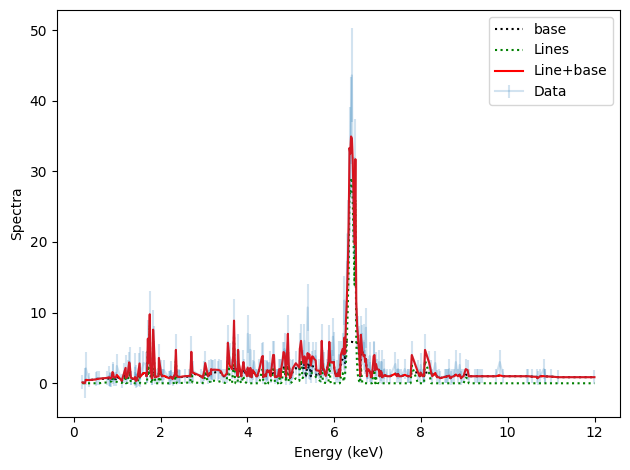

,center,sigma,amplitude,ecenter,esigma,eamplitude,base_on_line,value_on_line,noise_on_block,snr,relative_power,area,earea,ew,cluster_probability
0,0.906850,0.106653,0.283068,4.246240e-01,6.326535e-01,9.735241e-01,0.661234,1.038114,1.088344,0.260091,0.221780,0.075675,5.188878e-01,133.353762,0.77
1,0.903287,0.002769,45.013752,3.283793e-02,9.751847e-02,1.577811e+04,0.794956,1.587763,1.236580,36.401818,0.332732,0.312472,1.100783e+02,NaN,1.00
2,1.178785,0.006124,35.380486,2.473885e-02,5.830686e-02,2.731430e+03,1.105316,2.175527,1.317492,26.854412,0.326200,0.543075,4.224392e+01,NaN,1.00
3,1.280668,0.016856,1.733008,2.074559e-02,1.622847e-02,1.293743e+00,1.255447,2.725176,1.444934,1.199368,0.369221,0.073222,8.920623e-02,55.871529,0.77
4,1.507900,0.003440,68.351978,4.887128e+02,2.098651e+03,3.518820e+08,1.409535,2.801405,1.783365,38.327533,0.330537,0.589352,3.055270e+06,NaN,1.00
5,1.709794,0.002016,5.000082,2.624071e+07,8.437863e+07,1.861714e+04,1.445367,2.862588,1.486765,3.363062,0.328978,0.025264,1.057547e+09,42.769699,0.77
6,1.744389,0.010697,10.986039,4.103924e+01,1.301776e+01,2.427317e+04,1.508647,2.862588,1.994500,5.508166,0.309739,0.294570,7.430348e+02,94.740028,1.00
7,1.837982,0.003926,73.992770,5.513260e+02,3.081974e+03,3.162541e+08,1.641959,7.587763,1.831888,40.391532,0.644202,0.728118,3.164128e+06,NaN,1.00
8,1.964414,0.001313,6.112050,2.541830e+01,1.740935e+01,8.888369e+03,1.473277,3.587763,1.358746,4.498301,0.417797,0.020121,2.683224e+02,71.761348,1.00
9,2.346615,0.003939,33.607600,1.489546e+04,1.023879e+04,6.665561e+08,1.228575,4.725176,1.429909,23.503309,0.587294,0.331799,6.637018e+06,NaN,1.00


In [12]:
fx, fy, fsy = fits_spectrum.energy, fits_spectrum.values, fits_spectrum.uncertainties
valid = np.isfinite(fx) & np.isfinite(fy) & np.isfinite(fsy) & (fsy > 0)
fx, fy, fsy = fx[valid], fy[valid], fsy[valid]

# Optional: keep only positive values for the current emission-line workflow.
pos = fy > 0
fx, fy, fsy = fx[pos], fy[pos], fsy[pos]

# Use a modest rebinning for demonstration.
frx, fry, frsy = rebin_resolution(fx, fy, fsy, 0.02)

fits_lines = find_emission_lines(
    frx,
    fry,
    frsy,
    show_plot=True,
    output_dir=results_dir,
    plot_name="fits_bliss_fit.png",
)
fits_lines.to_csv(results_dir / "fits_candidate_lines.csv", index=False)
fits_lines

## 8. ISIS export from a BLiSS candidate table

The ISIS interface does not duplicate the BLiSS detection algorithm.

It takes the modular BLiSS candidate table and writes ISIS-compatible files:

```text
set_line_model_<name>.sl
set_line_parameters_<name>.sl
isis_candidates_<name>.csv
```

These names match the modular `create_line_model.sl` script included in the `isis/` folder.

In [13]:
isis_output_dir = results_dir / "isis_export"
isis_files = write_isis_line_model_files(
    xmm_lines,
    output_dir=isis_output_dir,
    model_name="xmm_demo",
    use_egauss=True,
)
isis_files

{'model_file': PosixPath('/Users/graciela/Desktop/git/BLiSS/results/2026-05-29_11-00-08_bliss/isis_export/set_line_model_xmm_demo.sl'),
 'parameter_file': PosixPath('/Users/graciela/Desktop/git/BLiSS/results/2026-05-29_11-00-08_bliss/isis_export/set_line_parameters_xmm_demo.sl'),
 'candidate_csv': PosixPath('/Users/graciela/Desktop/git/BLiSS/results/2026-05-29_11-00-08_bliss/isis_export/isis_candidates_xmm_demo.csv')}

In [14]:
print((isis_output_dir / "set_line_model_xmm_demo.sl").read_text()[:400])
print("---")
print((isis_output_dir / "set_line_parameters_xmm_demo.sl").read_text()[:800])

public define linemodel(){
	egauss(1) 
+egauss(2) 
+egauss(3) 
+egauss(4) 
+egauss(5) 
+egauss(6) 
+egauss(7) 
+egauss(8) 
+egauss(9) 
+egauss(10) 
+egauss(11) 
+egauss(12) 
+egauss(13) 
+egauss(14) 
+egauss(15) 
+egauss(16) 
+egauss(17) 
+egauss(18) 
+egauss(19) 
+egauss(20) 
+egauss(21) 
+egauss(22) 
+egauss(23) 
+egauss(24) 
+egauss(25) 
+egauss(26) 
;
}


---
set_par("egauss(1).center", 1.7230984623364523, 1, 1.6089461613453502, 1.8372507633275543);
set_par("egauss(2).center", 2.020009271710521, 1, 1.8387100941371803, 2.2013084492838617);
set_par("egauss(3).center", 2.3978624187367616, 1, 1.7754302937988886, 3.020294543674635);
set_par("egauss(4).center", 3.1705003608045437, 1, 3.006968226589027, 3.33403249502006);
set_par("egauss(5).center", 3.6969436770785613, 1, 3.6777180064746524, 3.71616934768247);
set_par("egauss(6).center", 4.317099821005494, 1, 3.742046370904891, 4.892153271106096);
set_par("egauss(7).center", 4.491370292562978, 1, 0, 193.93564284383152);
set_par("egauss(8)

## 9. ISIS command-line workflow

Inside ISIS, the expected workflow is:

```slang
variable MODEL_DIR = "/path/to/bliss_modular/isis";
evalfile(MODEL_DIR + "/create_line_model.sl");
create_line_model("myrun");
fit_line_model(&eval_counts, 1.0, 20, "myrun");
```

`create_line_model("myrun")` runs:

```bash
python -m bliss.isis_interface.run_bliss_for_isis myrun --spectrum spec_0.dat --output-dir .
```

and then loads:

```text
set_line_model_myrun.sl
set_line_parameters_myrun.sl
```

## 10. Summary of the modular user API

Common imports:

In [15]:
from bliss import load_text_spectrum, load_fits_spectrum
from bliss import rebin_snr, rebin_resolution, find_emission_lines
from bliss import add_most_probable_ion, plot_line_prob
from bliss.isis_interface import write_isis_line_model_files

Minimal text-file run:

In [16]:
x, y, sy, dx = load_text_spectrum(PROJECT_ROOT / "examples" / "xmm.dat")
rx, ry, rsy = rebin_snr(x, y, sy, 0.8)
lines = find_emission_lines(rx, ry, rsy)
lines.head()

,center,sigma,amplitude,ecenter,esigma,eamplitude,base_on_line,value_on_line,noise_on_block,snr,relative_power,area,earea,ew,cluster_probability
0,1.723098,0.106224,0.004762,0.057076,0.051994,0.000988,0.000848,0.005233,0.001439,3.310066,0.721138,0.001268,0.000674,1056.840180,0.00
1,2.020009,0.042951,0.000813,0.090650,0.096632,0.001354,0.001043,0.001569,0.000924,0.880431,0.201420,0.000088,0.000245,inf,0.00
2,2.397862,0.081581,0.000637,0.311216,0.279566,0.001614,0.000542,0.001192,0.000567,1.123720,0.374746,0.000130,0.000555,240.539801,0.00
3,3.170500,0.025173,0.001816,0.081766,0.036752,0.002705,0.000780,0.002473,0.000777,2.336755,0.520275,0.000115,0.000239,97.946703,0.76
4,3.696944,0.026663,0.005978,0.009613,0.007220,0.001511,0.001612,0.007593,0.001300,4.597864,0.649765,0.000400,0.000148,244.479429,1.00


Minimal FITS-file run:

In [ ]:
spec = load_fits_spectrum(
    PROJECT_ROOT / "examples" / "fits_spectrum_data" / "med4.ds",
    background_path=PROJECT_ROOT / "examples" / "fits_spectrum_data" / "bkglp.fits",
    rmf_path=PROJECT_ROOT / "examples" / "fits_spectrum_data" / "r_plateau.rmf",
)
lines_from_fits = find_emission_lines(spec.energy, spec.values, spec.uncertainties)
lines_from_fits.head()

Error fitting block 1: Each lower bound must be strictly less than each upper bound.
Error fitting block 3: Each lower bound must be strictly less than each upper bound.
Error fitting block 91: Optimal parameters not found: The maximum number of function evaluations is exceeded.
Error fitting block 125: Optimal parameters not found: The maximum number of function evaluations is exceeded.
